# Contrast Response Demo: Gratings

Flash has its own notebook (`5_flash_demo.ipynb`); spots are excluded for now (no example spot-contrast data yet).

To look through the raster/CRF plotting functions, refer to
`src/retinanalysis/utils/contrast_response_utils.py`.

**What this notebook gives you:**
- CRF curves: raw and noise-subtracted, non-normalized and per-cell-normalized (4
  panels), population mean +/- SEM vs. contrast. Uses F1 (periodic stimulus).
- Noise subtraction: baseline is the per-cell average F1 from this experiment's own
  0%-contrast trials, not a pre-stimulus window.
- Rasters, two ways: an overview grid with one representative cell per cell type,
  and a "pick a cell type, see every cell of that type" browser.
- Raster+PSTH pairing (sanity check that the PSTH curve is a fair summary of the
  raw spikes above it).
- Naka-Rushton fit for a single example cell.

`corr_cutoff` (the EI-matching threshold, MATLAB's `corr_threshold`) is a real,
settable parameter on `create_mea_pipeline`/`MEAPipeline` -- `CORR_THRESHOLD_GRATING`
below, defaulting to 0.85.


In [1]:
import retinanalysis as ra
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


C:\Users\Yasmine Tani\anaconda3\envs\retinanalysis\Lib\site-packages\datajoint\settings.py:992: UserWarning: No datajoint.json found. Using defaults and environment variables. Run `dj.config.save_template()` to create a template configuration.
  config = _create_config()


## Find contrast-response datasets

Broad substring search (`'contrast'`) -- deliberately not exact-match, since spot
and flash protocol names aren't confirmed yet. Check the printed
`protocol_name`s below and fill in each section's `_PROTOCOL_NAME` variable
accordingly.

In [2]:
contrast_search = ra.get_datasets_from_protocol_names('contrast')
print(contrast_search['protocol_name'].unique())
ra.scrollable_dataframe(contrast_search)


[2026-08-13 18:00:24] DataJoint 2.2.2 connected to root@127.0.0.1:3306

Found 3 protocols matching "contrast":
['manookinlab.protocols.ContrastResponseFlash'
 'manookinlab.protocols.ContrastResponseGrating'
 'manookinlab.protocols.ContrastResponseSpot']

Found 24 experiments, 204 epoch blocks.

<StringArray>
[   'manookinlab.protocols.ContrastResponseSpot',
   'manookinlab.protocols.ContrastResponseFlash',
 'manookinlab.protocols.ContrastResponseGrating']
Length: 3, dtype: str


,exp_name,datafile_name,NDF,chunk_name,protocol_name,is_mea,data_dir,group_label,experiment_id,protocol_id,group_id,block_id,chunk_id
0,20250912A,data009,3.0,data009,manookinlab.protocols.ContrastResponseSpot,1,20250912A\data009,Control,395,6,1419,4148,3753
1,20250918A,data004,5.0,data004,manookinlab.protocols.ContrastResponseSpot,1,20250918A\data004,Control,396,6,1420,4153,3758
2,20250918A,data008,4.0,data008,manookinlab.protocols.ContrastResponseSpot,1,20250918A\data008,Control,396,6,1420,4157,3762
3,20250918A,data012,3.0,data012,manookinlab.protocols.ContrastResponseSpot,1,20250918A\data012,Control,396,6,1420,4161,3766
4,20250918A,data016,2.0,data016,manookinlab.protocols.ContrastResponseSpot,1,20250918A\data016,Control,396,6,1420,4165,3770
5,20250918A,data020,1.0,data020,manookinlab.protocols.ContrastResponseSpot,1,20250918A\data020,Control,396,6,1420,4169,3774
6,20250918A,data021,0.0,data021,manookinlab.protocols.ContrastResponseSpot,1,20250918A\data021,Control,396,6,1420,4170,3775
7,20250918A,data001,5.0,data001,manookinlab.protocols.ContrastResponseFlash,1,20250918A\data001,Control,396,7,1420,4150,3755
8,20250918A,data002,5.0,data002,manookinlab.protocols.ContrastResponseFlash,1,20250918A\data002,Control,396,7,1420,4151,3756
9,20250918A,data007,4.0,data007,manookinlab.protocols.ContrastResponseFlash,1,20250918A\data007,Control,396,7,1420,4156,3761


## Choose an experiment (shared across all sections)

Only `exp_name` needs to be set. The white-noise/cell-typing chunk is found once
here (`ra.find_classified_noise_chunk`, same picker as the DS/OS demo -- prefers
a classified NDF0 chunk, falls back to NDF1, prints what it found) and reused by
every section below, since cell typing doesn't depend on which contrast stimulus
is being analyzed. Set `MANUAL_ANALYSIS_CHUNK` to override.

In [27]:
exp_name = '20260729A'

MANUAL_ANALYSIS_CHUNK = None  # e.g. 'chunk13' or 'data001' -- set this to skip auto-detection

analysis_chunk_name = MANUAL_ANALYSIS_CHUNK or ra.find_classified_noise_chunk(exp_name)
if analysis_chunk_name is None:
    print(
        'No classified NDF0/NDF1 white-noise chunk found -- each section below will '
        'fall back to create_mea_pipeline\'s own nearest-chunk logic. This may crash; '
        'if so, set MANUAL_ANALYSIS_CHUNK above to a chunk you know is classified.'
    )


DataJointError: Attribute `chunk_id` already exists

## Load cell typing (shared across all sections)

Builds an `AnalysisChunk` for the chunk found above just to read its
classification file(s) -- `b_load_spatial_maps=False`/`include_ei=False` since
none of this notebook needs RF maps or EIs, only the cell_id -> cell_type
mapping. If the chunk has more than one classification file, the first one found
is used by default; set `PREFERRED_TYPING_FILE` to pick a specific one.

Falls back to assuming no STA cropping (with a printed warning) if a chunk's
`.globals` file is missing the RTMP tag, and prints a one-time diagnostic (raw
label text + current vocabulary) if over half the cells come back "Unknown" --
usually means `assets/cell_types.csv` doesn't have this lab's real type strings yet.


In [12]:
PREFERRED_TYPING_FILE = None  # e.g. 'chunk13.classificationYT.txt' -- set to pick a specific file

cell_type_map = pd.Series(dtype=object)

if analysis_chunk_name is not None:
    typing_chunk = ra.AnalysisChunk(
        exp_name, analysis_chunk_name, b_load_spatial_maps=False, include_ei=False, verbose=False,
    )
    classification_files = [f for f in typing_chunk.typing_files if 'classification' in f.lower()]
    if not classification_files:
        print(f'{analysis_chunk_name} has no classification file -- cell_type will be "Unknown" for every cell.')
    else:
        chosen_file = (
            PREFERRED_TYPING_FILE if PREFERRED_TYPING_FILE in classification_files
            else classification_files[0]
        )
        if len(classification_files) > 1:
            print(f'Multiple classification files found: {classification_files}. Using {chosen_file}.')
        file_idx = typing_chunk.typing_files.index(chosen_file)
        cell_type_map = pd.Series(
            typing_chunk.df_cell_params[f'typing_file_{file_idx}'].values,
            index=typing_chunk.cell_ids,
        )
        print(f'Loaded cell types for {len(cell_type_map)} cells from {chosen_file}.')
        print(cell_type_map.value_counts())

        if len(cell_type_map) > 0 and (cell_type_map == 'Unknown').mean() > 0.5:
            print()
            print('Over half of cells are "Unknown" -- likely a cell_types.csv vocabulary '
                  'mismatch, not a real absence of classifications.')
            typing_file_path = typing_chunk._resolve_typing_file_path(chosen_file)
            if typing_file_path is not None:
                print(f'Raw lines from {typing_file_path}:')
                with open(typing_file_path, 'r') as f:
                    raw_lines = [line.strip() for line in f if line.strip()][:5]
                for line in raw_lines:
                    print(f'  {line!r}')
            else:
                print(f'Could not resolve a file path for {chosen_file} to show raw content.')
            import importlib.resources as ir
            import retinanalysis
            cell_types_csv_path = str(ir.files(retinanalysis) / 'assets/cell_types.csv')
            with open(cell_types_csv_path, 'r') as f:
                csv_entries = [l.strip() for l in f if l.strip() and l.strip() != 'cell_types']
            print(f'Current assets/cell_types.csv vocabulary ({len(csv_entries)} entries): {csv_entries}')
else:
    print('No analysis_chunk_name -- skipping cell typing, every cell will show as "Unknown".')


Loaded cell types for 470 cells from data010_classificationMC.txt.
Unknown    329
OffS       141
Name: count, dtype: int64

Over half of cells are "Unknown" -- likely a cell_types.csv vocabulary mismatch, not a real absence of classifications.
Raw lines from B:\Array-data\sorted\20260730A\kilosort25\data010\data010_classificationMC.txt:
  '15  All/OFFsus/'
  '33  All/OFFsus/'
  '38  All/OFFsus/'
  '47  All/OFFsus/'
  '49  All/OFFsus/'
Current assets/cell_types.csv vocabulary (41 entries): ['OnP', 'OffP', 'LOnM', 'MOnM', 'OnM', 'BlueOffM', 'LOffM', 'MOffM', 'OffM', 'OnS', 'OffS', 'SBC', 'BT', 'OnMystery', 'OffMystery', 'OffBoring', 'OnWiggles', 'OnLarge', 'OffLarge', 'Xmas', 'RB', 'Tufted', 'BlueMystery', 'A1', 'OnAmacrine', 'OffAmacrine', 'BlueAmacrine', 'Amacrine', 'InterestingIfTrue', 'BigMas', 'Spotty', 'Shadow', 'Blobby', 'BluePeaky', 'on/brisk sustained', 'on/brisk transient', 'brisk sustained', 'brisk transient', 'transient', 'on cells', 'off cells']


## Shared response-extraction and plotting functions

Defined in `src/retinanalysis/utils/contrast_response_utils.py` and imported below; used
by all three sections.

- `load_contrast_section(...)`: finds the datafile for a given protocol (via
  `ra.find_datafile_for_protocol`), builds the pipeline (reusing the shared
  `analysis_chunk_name` from above, with a settable `corr_cutoff` EI-matching threshold),
  builds the tidy response table (via `ra.build_trial_response_table`), tags each row with
  its `cell_type` (from `pipeline.resp.df_spike_times`, via `MEAPipeline`'s own EI-based
  cross-chunk cell mapping), and prints `epoch_parameters` keys for verification.
- `plot_crf(...)`: raw vs. noise-subtracted (rows, `show_noise_sub=False` to skip the
  noise-subtracted row) x non-normalized vs. per-cell-normalized (cols) -- population mean
  +/- SEM vs. condition.
- `plot_raster_overview_by_cell_type(...)` / `plot_rasters_for_cell_type(...)`: one figure
  PER cell type (not one combined grid) with a representative sample of cells, and every
  cell of a chosen type, paginated.

**Cell-type bookkeeping labels:** `'Unmatched'` means a cell never EI-matched the reference
classification chunk at all; `'Unknown'` means it matched but its classification label was
blank/unrecognized. Both are excluded from cell-type lists by default -- if most cells come
out "Unknown", check whether `assets/cell_types.csv` has your lab's actual mouse cell-type
vocabulary (see the typing cell above).


In [13]:
from retinanalysis.utils.contrast_response_utils import *


---
# Section: Gratings (`ContrastResponseGrating`)

Protocol name confirmed from earlier real search results:
`manookinlab.protocols.ContrastResponseGrating`. Periodic stimulus (has
`temporalFrequency`), so this section uses F1 as the response measure --
`f1`/`f1_noise_sub` from `build_trial_response_table`.

In [14]:
GRATING_PROTOCOL_NAME = 'manookinlab.protocols.ContrastResponseGrating'
MANUAL_DATAFILE_NAME_GRATING = None  # e.g. 'data015' -- set to skip auto-detection
CORR_THRESHOLD_GRATING = 0.85  # EI-matching cutoff (reference chunk <-> this datafile)

# Progress/diagnostic prints collapse into a scrollable box -- doesn't change the loaded data.
with scrollable_prints():
    df_trials_grating, spike_times_by_cell_grating, df_epochs_grating, datafile_name_grating, ndf_grating = load_contrast_section(
        exp_name, contrast_search, GRATING_PROTOCOL_NAME, condition_keys=['contrast'],
        analysis_chunk_name=analysis_chunk_name, corr_cutoff=CORR_THRESHOLD_GRATING,
        manual_datafile_name=MANUAL_DATAFILE_NAME_GRATING, typing_chunk=typing_chunk,
        baseline_condition_key='contrast', baseline_condition_value=0.0,
    )


## Grating CRF (F1-based)

Raw and noise-subtracted F1 vs. contrast, population mean +/- SEM. Noise subtraction uses each cell's own 0%-contrast trials as baseline (not a pre-stimulus window); x-axis is linear with evenly-spaced tested contrast values as labels.


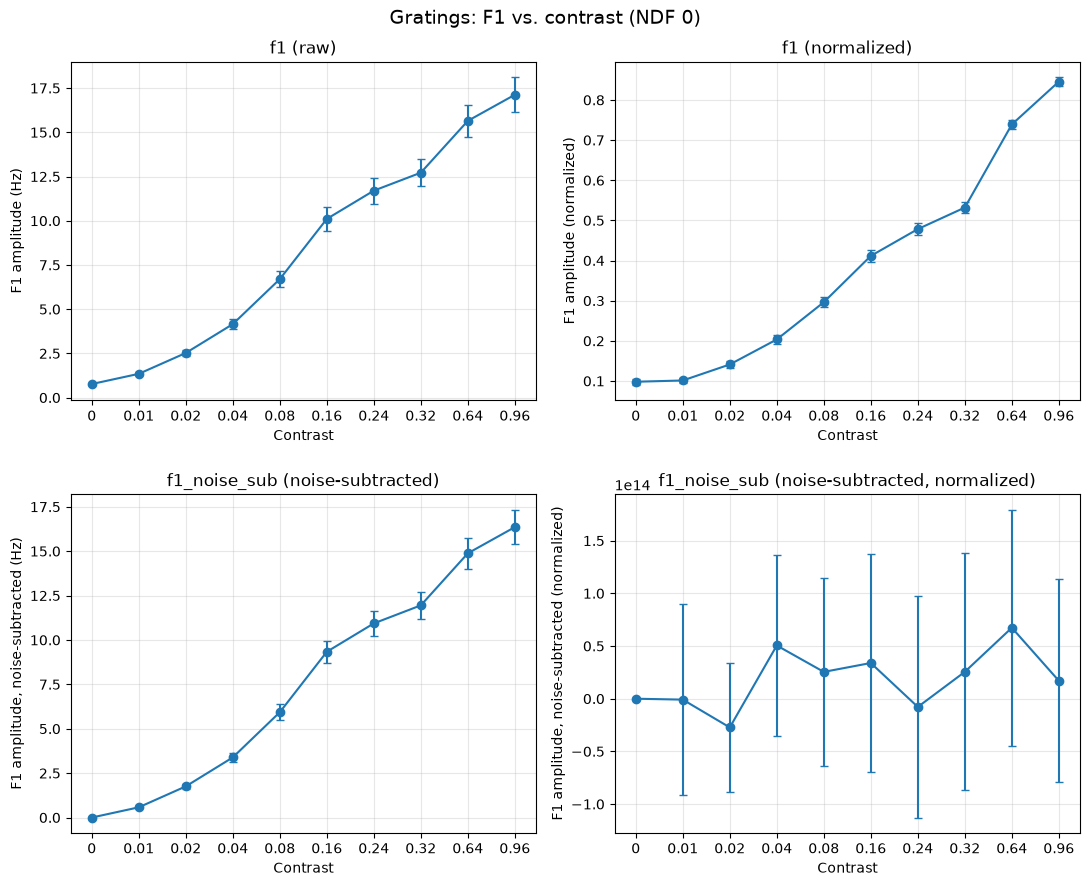

In [15]:
fig = plot_crf(
    df_trials_grating, condition_key='contrast',
    response_col='f1_noise_sub', raw_response_col='f1',
    title=f'Gratings: F1 vs. contrast (NDF {ndf_grating})',
    show_noise_sub=True, log_x=False, even_spacing=True,
)
# fig.savefig(f'{exp_name}_grating_crf.png', dpi=300, bbox_inches='tight')  # uncomment to save this figure


Same plot, true-to-scale log-x axis instead of the evenly-spaced linear one.

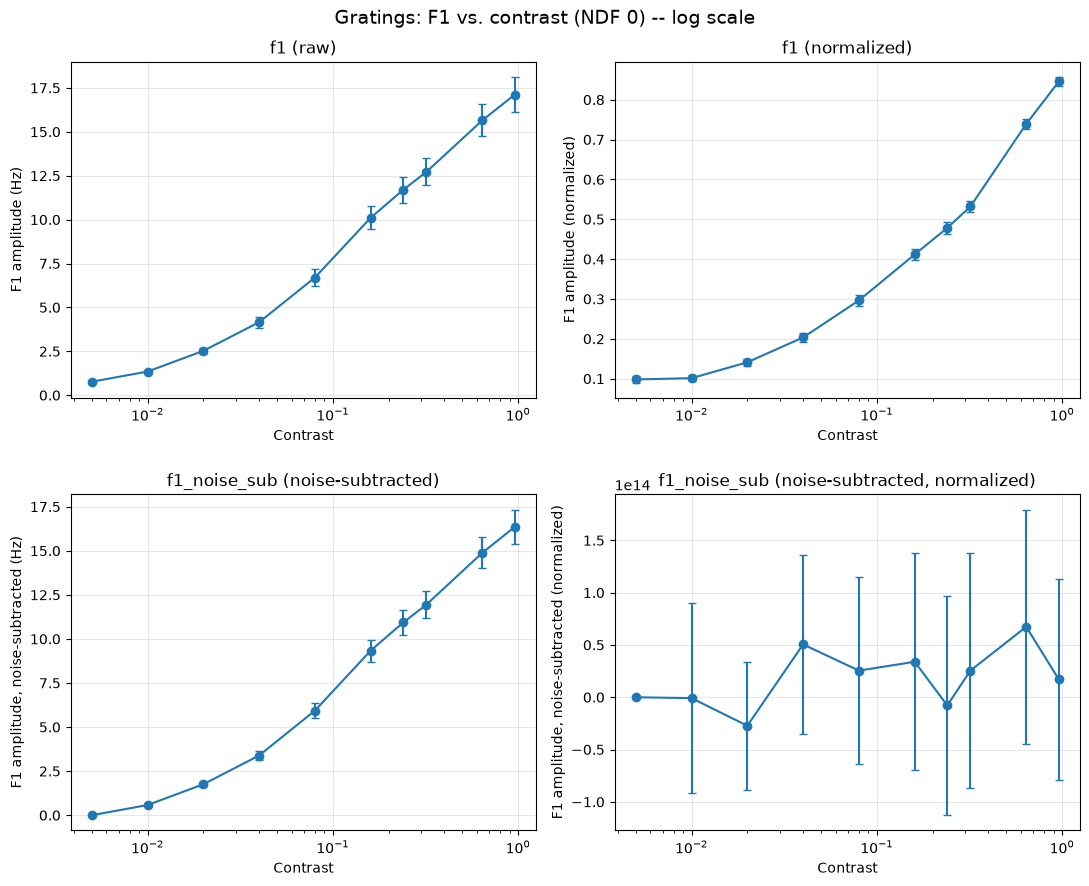

In [16]:
fig = plot_crf(
    df_trials_grating, condition_key='contrast',
    response_col='f1_noise_sub', raw_response_col='f1',
    title=f'Gratings: F1 vs. contrast (NDF {ndf_grating}) -- log scale',
    show_noise_sub=True, log_x=True,
)
# fig.savefig(f'{exp_name}_grating_crf_log.png', dpi=300, bbox_inches='tight')  # uncomment to save this figure


### CRF across all NDFs, one figure per cell type

Loops every NDF found for `GRATING_PROTOCOL_NAME` (via `ra.get_ndf_blocks_for_protocol`,
real database NDF values, not a hardcoded list) and overlays each NDF's population CRF as
its own line/color on shared axes. Produces one figure per real cell type (auto-detected
across every loaded NDF, excluding `'Unknown'`/`'Unmatched'`) -- each figure's title names
the cell type. Uses raw `'f1'` (not noise-subtracted), same reasoning as the single-NDF
cell above. Data is loaded once per NDF (not once per NDF per type).

Reloads and re-matches cells at every NDF (same per-NDF cost as running the "explore a
different NDF" cell once per NDF below), so this can take a while -- progress prints
collapse into a scrollable box (`scrollable_prints`, in contrast_response_utils.py).

Set `SHOW_SEM_ACROSS_NDFS = False` in the cell below to hide the SEM error bars (useful but can make the plot busy with many NDFs overlaid).


20260730A: found 5 NDF level(s) for 'manookinlab.protocols.ContrastResponseGrating': [0.0, 2.0, 3.0, 4.0, 5.0]


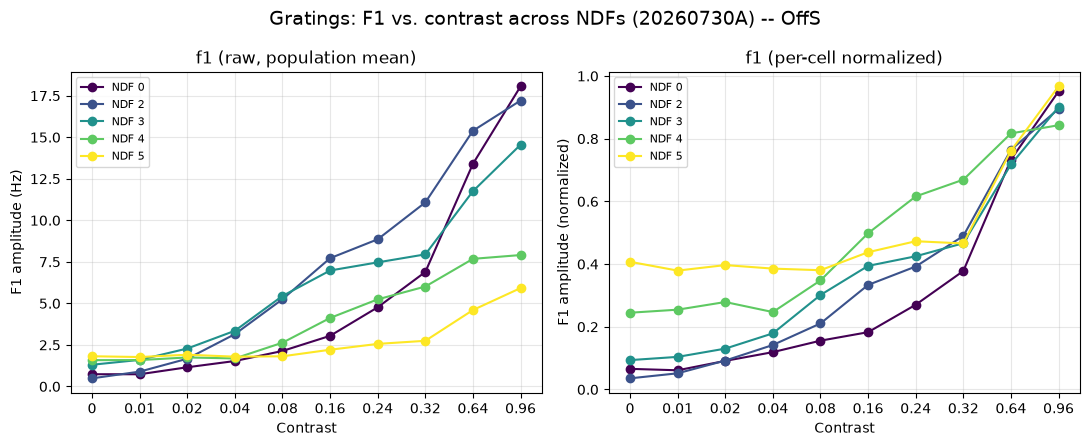

In [18]:
SHOW_SEM_ACROSS_NDFS = False  # quick on/off for the SEM error bars on these plots

figs_crf_all_ndfs_grating = plot_crf_across_ndfs(
    exp_name, contrast_search, GRATING_PROTOCOL_NAME, condition_key='contrast',
    analysis_chunk_name=analysis_chunk_name, corr_cutoff=CORR_THRESHOLD_GRATING,
    response_col='f1', typing_chunk=typing_chunk,
    baseline_condition_key='contrast', baseline_condition_value=0.0,
    title_prefix=f'Gratings: F1 vs. contrast across NDFs ({exp_name})',
    show_sem=SHOW_SEM_ACROSS_NDFS, log_x=False, even_spacing=True,
)
# for cell_type, f in figs_crf_all_ndfs_grating.items():
#     f.savefig(f'{exp_name}_{cell_type}_crf_across_ndfs.png', dpi=300, bbox_inches='tight')  # uncomment to save


Same plot, true-to-scale log-x axis instead of the evenly-spaced linear one.

20260730A: found 5 NDF level(s) for 'manookinlab.protocols.ContrastResponseGrating': [0.0, 2.0, 3.0, 4.0, 5.0]


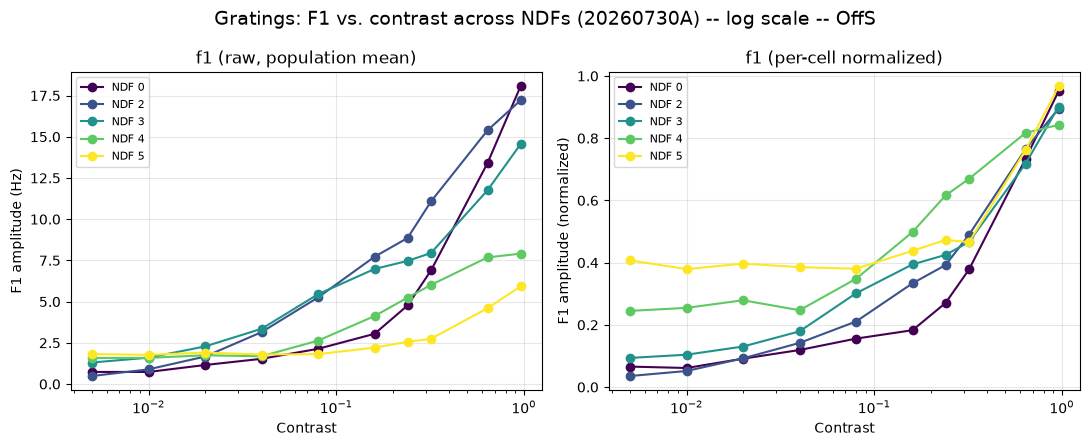

In [19]:
figs_crf_all_ndfs_grating_log = plot_crf_across_ndfs(
    exp_name, contrast_search, GRATING_PROTOCOL_NAME, condition_key='contrast',
    analysis_chunk_name=analysis_chunk_name, corr_cutoff=CORR_THRESHOLD_GRATING,
    response_col='f1', typing_chunk=typing_chunk,
    baseline_condition_key='contrast', baseline_condition_value=0.0,
    title_prefix=f'Gratings: F1 vs. contrast across NDFs ({exp_name}) -- log scale',
    show_sem=SHOW_SEM_ACROSS_NDFS, log_x=True,
)
# for cell_type, f in figs_crf_all_ndfs_grating_log.items():
#     f.savefig(f'{exp_name}_{cell_type}_crf_across_ndfs_log.png', dpi=300, bbox_inches='tight')  # uncomment to save


### Noise-subtracted version of the plots above

Same calls as above with `response_col='f1_noise_sub'` instead of raw `'f1'`, matching what the single-NDF CRF cells show (raw and noise-subtracted side by side).


20260730A: found 5 NDF level(s) for 'manookinlab.protocols.ContrastResponseGrating': [0.0, 2.0, 3.0, 4.0, 5.0]


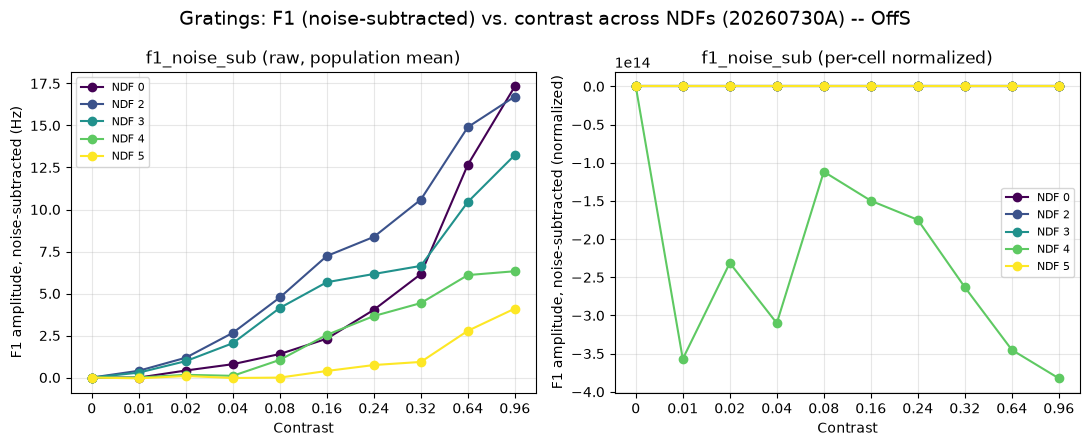

In [20]:
figs_crf_all_ndfs_grating_noise_sub = plot_crf_across_ndfs(
    exp_name, contrast_search, GRATING_PROTOCOL_NAME, condition_key='contrast',
    analysis_chunk_name=analysis_chunk_name, corr_cutoff=CORR_THRESHOLD_GRATING,
    response_col='f1_noise_sub', typing_chunk=typing_chunk,
    baseline_condition_key='contrast', baseline_condition_value=0.0,
    title_prefix=f'Gratings: F1 (noise-subtracted) vs. contrast across NDFs ({exp_name})',
    show_sem=SHOW_SEM_ACROSS_NDFS, log_x=False, even_spacing=True,
)
# for cell_type, f in figs_crf_all_ndfs_grating_noise_sub.items():
#     f.savefig(f'{exp_name}_{cell_type}_crf_across_ndfs_noise_sub.png', dpi=300, bbox_inches='tight')  # uncomment to save


Same plot, true-to-scale log-x axis instead of the evenly-spaced linear one.

20260730A: found 5 NDF level(s) for 'manookinlab.protocols.ContrastResponseGrating': [0.0, 2.0, 3.0, 4.0, 5.0]


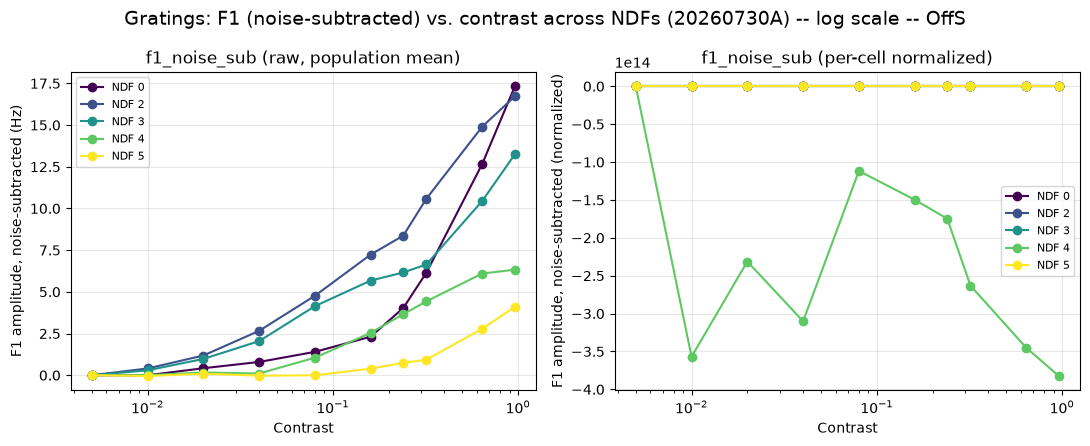

In [21]:
figs_crf_all_ndfs_grating_noise_sub_log = plot_crf_across_ndfs(
    exp_name, contrast_search, GRATING_PROTOCOL_NAME, condition_key='contrast',
    analysis_chunk_name=analysis_chunk_name, corr_cutoff=CORR_THRESHOLD_GRATING,
    response_col='f1_noise_sub', typing_chunk=typing_chunk,
    baseline_condition_key='contrast', baseline_condition_value=0.0,
    title_prefix=f'Gratings: F1 (noise-subtracted) vs. contrast across NDFs ({exp_name}) -- log scale',
    show_sem=SHOW_SEM_ACROSS_NDFS, log_x=True,
)
# for cell_type, f in figs_crf_all_ndfs_grating_noise_sub_log.items():
#     f.savefig(f'{exp_name}_{cell_type}_crf_across_ndfs_noise_sub_log.png', dpi=300, bbox_inches='tight')  # uncomment to save


## Grating Naka-Rushton fit

Per-cell fit of `R(c) = baseline + Rmax*c^n/(c^n+c50^n)` to each cell's F1, normalized to its own max -- fits use raw `f1`, not noise-subtracted, since Naka-Rushton assumes a non-negative saturating response. Shows the single best-fitting cell (highest R-squared) as a sanity check that the fit tracks the real data; `df_fits_grating` below has every cell's own fitted c50/r_squared if you want the population numbers.


In [ ]:
contrast_curves_grating = (
    df_trials_grating.groupby(['cell_id', 'contrast'])['f1'].mean().reset_index()
)

fit_rows = []
normalized_curves = []
n_cells_dropped = 0

for cell_id, grp in contrast_curves_grating.groupby('cell_id'):
    grp = grp.sort_values('contrast')
    max_val = grp['f1'].max()
    if max_val is None or not np.isfinite(max_val) or max_val <= 0:
        n_cells_dropped += 1
        continue
    norm_vals = grp['f1'].values / max_val
    normalized_curves.append(pd.DataFrame({
        'cell_id': cell_id, 'contrast': grp['contrast'].values, 'f1_norm': norm_vals,
    }))
    try:
        fit = ra.fit_naka_rushton(grp['contrast'].values, norm_vals)
        fit['cell_id'] = cell_id
        fit_rows.append(fit)
    except RuntimeError as e:
        print(f'Naka-Rushton fit failed for cell {cell_id}, skipping: {e}')

df_normalized_grating = pd.concat(normalized_curves, ignore_index=True) if normalized_curves else pd.DataFrame()
df_fits_grating = pd.DataFrame(fit_rows)
print(f'{n_cells_dropped} cells dropped (no positive F1 at any contrast)')
print(f'{len(df_fits_grating)} cells with a successful Naka-Rushton fit')

if len(df_fits_grating) > 0:
    display(df_fits_grating.sort_values('r_squared', ascending=False).head(10))

    example_cell_id = df_fits_grating.sort_values('r_squared', ascending=False).iloc[0]['cell_id']
    example_fit = df_fits_grating.query('cell_id == @example_cell_id').iloc[0]
    example_curve = df_normalized_grating.query('cell_id == @example_cell_id').sort_values('contrast')

    from retinanalysis.utils.tuning import _naka_rushton
    c_smooth = np.linspace(0, example_curve['contrast'].max(), 200)
    fit_smooth = _naka_rushton(c_smooth, example_fit['rmax'], example_fit['c50'], example_fit['n'], example_fit['baseline'])

    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    ax.plot(example_curve['contrast'], example_curve['f1_norm'], 'o', label='data')
    ax.plot(c_smooth, fit_smooth, '-', label=f'fit (C50={example_fit["c50"]:.3f}, n={example_fit["n"]:.2f}, R²={example_fit["r_squared"]:.3f})')
    ax.set_xlabel('Contrast'); ax.set_ylabel('F1 (normalized)')
    ax.set_title(f'Cell {example_cell_id}'); ax.legend(); ax.grid(True)
    fig.tight_layout()


## Grating PSTHs (raster + PSTH pairing, sanity check before looking at the rasters below)

The standard QC pairing: raster on top, its derived PSTH directly below, same time
axis, per cell. 10ms bins by default -- unrelated to how F1 itself gets computed
(`compute_f1_f0_from_spikes` in `tuning.py` uses raw spike phases, no binning at all).

The PSTH panel is one single box -- same shape/size as the raster above it -- with
every contrast's PSTH trace drawn in its own horizontal band inside that box, stacked
bottom-to-top in the same order as the raster's own condition blocks (lowest contrast
at the bottom, highest at the top), each band labeled on the y-axis exactly like the
raster's own blocks are. No limit on how many contrast levels fit -- more conditions
just means more (thinner) bands in the same box. See
`plot_raster_and_psth_for_cell_type`'s docstring (`contrast_response_utils.py`) for
the full reasoning.

Paginated (`max_cells_per_page`, default 4).


In [ ]:
PSTH_NDF_VALUES = [ndf_grating]  # e.g. [ndf_grating] (just this NDF) or [1, 2, 3] -- which NDF(s) to show raster+PSTH pairs for
PSTH_BIN_SIZE_MS = 10.0  # matches yas's MATLAB PSTH convention
PSTH_CELL_TYPE_GRATING = None  # e.g. 'on brisk transient' -- None picks the first real (non-Unknown/Unmatched) cell type

_real_types_for_psth_grating = sorted(
    t for t in df_trials_grating['cell_type'].unique() if t not in ('Unknown', 'Unmatched')
)
psth_cell_type_grating = PSTH_CELL_TYPE_GRATING or (
    _real_types_for_psth_grating[0] if _real_types_for_psth_grating
    else sorted(df_trials_grating['cell_type'].unique())[0]
)
print(f'Raster+PSTH for cell type: {psth_cell_type_grating!r} (available: {sorted(df_trials_grating["cell_type"].unique())})')

df_ndf_blocks_psth_grating = ra.get_ndf_blocks_for_protocol(exp_name, GRATING_PROTOCOL_NAME)

figs_raster_psth_grating = []
for ndf_val in PSTH_NDF_VALUES:
    if ndf_val == ndf_grating:
        # Already loaded above -- reuse it instead of reloading.
        df_trials_ndf, spike_times_by_cell_ndf, df_epochs_ndf = (
            df_trials_grating, spike_times_by_cell_grating, df_epochs_grating,
        )
    else:
        match = df_ndf_blocks_psth_grating[df_ndf_blocks_psth_grating['NDF'] == ndf_val]
        if len(match) == 0:
            print(f'No {GRATING_PROTOCOL_NAME} block found at NDF {ndf_val}. '
                  f'Available NDFs: {list(df_ndf_blocks_psth_grating["NDF"])}')
            continue
        explore_datafile = match.iloc[0]['datafile_name']
        print(f'Loading NDF {ndf_val} ({explore_datafile}) for raster+PSTH...')
        with scrollable_prints():
            df_trials_ndf, spike_times_by_cell_ndf, df_epochs_ndf, _, _ = load_contrast_section(
                exp_name, contrast_search, GRATING_PROTOCOL_NAME, condition_keys=['contrast'],
                analysis_chunk_name=analysis_chunk_name, corr_cutoff=CORR_THRESHOLD_GRATING,
                manual_datafile_name=explore_datafile,
                baseline_condition_key='contrast', baseline_condition_value=0.0,
            )
    print(f'--- NDF {ndf_val} ---')
    figs_ndf = plot_raster_and_psth_for_cell_type(
        df_trials_ndf, spike_times_by_cell_ndf, df_epochs_ndf, 'contrast', psth_cell_type_grating,
        bin_size_ms=PSTH_BIN_SIZE_MS,
    )
    figs_raster_psth_grating.extend(figs_ndf)


## Grating rasters

Overview grid (one representative cell per type), then a browser for every cell of a chosen type.

In [ ]:
raster_figs_grating = plot_raster_overview_by_cell_type(
    df_trials_grating, spike_times_by_cell_grating, df_epochs_grating,
    condition_key='contrast', response_col='f1',
)


In [ ]:
_real_types_grating = sorted(
    t for t in df_trials_grating['cell_type'].unique() if t not in ('Unknown', 'Unmatched')
)
SELECTED_CELL_TYPE_GRATING = (
    _real_types_grating[0] if _real_types_grating
    else sorted(df_trials_grating['cell_type'].unique())[0]
)  # change to any type printed below
print(f'Selected cell type: {SELECTED_CELL_TYPE_GRATING!r} (available: {sorted(df_trials_grating["cell_type"].unique())})')

raster_figs_grating_selected = plot_rasters_for_cell_type(
    df_trials_grating, spike_times_by_cell_grating, df_epochs_grating,
    condition_key='contrast', selected_cell_type=SELECTED_CELL_TYPE_GRATING,
)


### Optional: look at a different NDF (light level) or cell type

Reruns this section's rasters at a different light level, using the same protocol
(`GRATING_PROTOCOL_NAME`) but a different NDF's datafile -- found dynamically via
`ra.get_ndf_blocks_for_protocol` (the same helper demo 8 uses), not a hardcoded
NDF -> datafile mapping. Leave `EXPLORE_NDF_GRATING = None` to skip this.

In [ ]:
EXPLORE_NDF_GRATING = 2.0  # e.g. 2.0 -- set to an NDF value to look at a different light level. can set to none
EXPLORE_CELL_TYPE_GRATING = 'off brisk transient'  # e.g. 'off brisk sustained' -- None reuses SELECTED_CELL_TYPE_GRATING

if EXPLORE_NDF_GRATING is not None:
    df_ndf_blocks_grating = ra.get_ndf_blocks_for_protocol(exp_name, GRATING_PROTOCOL_NAME)
    match = df_ndf_blocks_grating[df_ndf_blocks_grating['NDF'] == EXPLORE_NDF_GRATING]
    if len(match) == 0:
        print(f'No {GRATING_PROTOCOL_NAME} block found at NDF {EXPLORE_NDF_GRATING} for {exp_name}. '
              f'Available NDFs: {list(df_ndf_blocks_grating["NDF"])}')
    else:
        explore_datafile = match.iloc[0]['datafile_name']
        print(f'Loading NDF {EXPLORE_NDF_GRATING} ({explore_datafile}) ...')
        # Loading prints collapse into a scrollable box; the raster figures below
        # render normally.
        with scrollable_prints():
            df_trials_explore, spike_times_by_cell_explore, df_epochs_explore, _, _ = load_contrast_section(
                exp_name, contrast_search, GRATING_PROTOCOL_NAME, condition_keys=['contrast'],
                analysis_chunk_name=analysis_chunk_name, corr_cutoff=CORR_THRESHOLD_GRATING,
                manual_datafile_name=explore_datafile,
                baseline_condition_key='contrast', baseline_condition_value=0.0,
            )
        explore_cell_type = EXPLORE_CELL_TYPE_GRATING or SELECTED_CELL_TYPE_GRATING
        raster_figs_explore_grating = plot_rasters_for_cell_type(
            df_trials_explore, spike_times_by_cell_explore, df_epochs_explore,
            condition_key='contrast', selected_cell_type=explore_cell_type,
        )
else:
    print('EXPLORE_NDF_GRATING is None -- skipping. Set it to an NDF value to explore a different light level.')
